# Working with Order Book Data: NASDAQ ITCH

The primary source of market data is the order book, which is continuously updated in real-time throughout the day to reflect all trading activity. Exchanges typically offer this data as a real-time service and may provide some historical data for free.

The trading activity is reflected in numerous messages about trade orders sent by market participants. These messages typically conform to the electronic Financial Information eXchange (FIX) communications protocol for real-time exchange of securities transactions and market data or a native exchange protocol. 

## Background

### The FIX Protocol

Just like SWIFT is the message protocol for back-office (example, for trade-settlement) messaging, the [FIX protocol](https://www.fixtrading.org/standards/) is the de facto messaging standard for communication before and during, trade execution between exchanges, banks, brokers, clearing firms, and other market participants. Fidelity Investments and Salomon Brothers introduced FIX in 1992 to facilitate electronic communication between broker-dealers and institutional clients who by then exchanged information over the phone.

It became popular in global equity markets before expanding into foreign exchange, fixed income and derivatives markets, and further into post-trade to support straight-through processing. Exchanges provide access to FIX messages as a real-time data feed that is parsed by algorithmic traders to track market activity and, for example, identify the footprint of market participants and anticipate their next move. 

### Nasdaq TotalView-ITCH Order Book data

While FIX has a dominant large market share, exchanges also offer native protocols. The Nasdaq offers a [TotalView ITCH direct data-feed protocol](http://www.nasdaqtrader.com/content/technicalsupport/specifications/dataproducts/NQTVITCHspecification.pdf) that allows subscribers to track 
individual orders for equity instruments from placement to execution or cancellation.

As a result, it allows for the reconstruction of the order book that keeps track of the list of active-limit buy and sell orders for a specific security or financial instrument. The order book reveals the market depth throughout the day by listing the number of shares being bid or offered at each price point. It may also identify the market participant responsible for specific buy and sell orders unless it is placed anonymously. Market depth is a key indicator of liquidity and the potential price impact of sizable market orders. 

The ITCH v5.0 specification declares over 20 message types related to system events, stock characteristics, the placement and modification of limit orders, and trade execution. It also contains information about the net order imbalance before the open and closing cross.

## Imports

In [3]:
import gzip
import shutil
from pathlib import Path
from urllib.request import urlretrieve
from urllib.parse import urljoin
from clint.textui import progress
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from struct import unpack
from collections import namedtuple, Counter
from datetime import timedelta
from time import time

## Get NASDAQ ITCH Data from FTP Server

The Nasdaq offers [samples](ftp://emi.nasdaq.com/ITCH/) of daily binary files for several months. 

We are now going to illustrates how to parse a sample file of ITCH messages and reconstruct both the executed trades and the order book for any given tick.

The data is fairly large and running the entire example can take a lot of time and require substantial memory (16GB+). Also, the sample file used in this example may no longer be available because NASDAQ occasionaly updates the sample files.

The following table shows the frequency of the most common message types for the sample file date March 29, 2018:

| Name                    | Offset  | Length  | Value      | Notes                                                                                |
|-------------------------|---------|---------|------------|--------------------------------------------------------------------------------------|
| Message Type            | 0       | 1       | S          | System Event Message                                                                 |
| Stock Locate            | 1       | 2       | Integer    | Always 0                                                                             |
| Tracking Number         | 3       | 2       | Integer    | Nasdaq internal tracking number                                                      |
| Timestamp               | 5       | 6       | Integer    | Nanoseconds since midnight                                                           |
| Order Reference Number  | 11      | 8       | Integer    | The unique reference number assigned to the new order at the time of receipt.        |
| Buy/Sell Indicator      | 19      | 1       | Alpha      | The type of order being added. B = Buy Order. S = Sell Order.                        |
| Shares                  | 20      | 4       | Integer    | The total number of shares associated with the order being added to the book.        |
| Stock                   | 24      | 8       | Alpha      | Stock symbol, right padded with spaces                                               |
| Price                   | 32      | 4       | Price (4)  | The display price of the new order. Refer to Data Types for field processing notes.  |
| Attribution             | 36      | 4       | Alpha      | Nasdaq Market participant identifier associated with the entered order               |

### Set Data paths

We will store the download in a `data` subdirectory and convert the result to `hdf` format (discussed in the last section of chapter 2).

In [4]:
data_path = Path('../../data') # set to e.g. external harddrive
itch_store = str(data_path / 'itch.h5')
order_book_store = data_path / 'order_book.h5'

The FTP address, filename and corresponding date used in this example:

This is already updated from the 2018 example used in the book:

In [ ]:
SOURCE_FILE = '03272019.NASDAQ_ITCH50.gz'
base = 'https://emi.nasdaq.com/ITCH/Nasdaq%20ITCH'

### Download & unzip

The file is listed in the following URL:
https://emi.nasdaq.com/ITCH/Nasdaq%20ITCH/

The sepcific file we want to download is:
https://emi.nasdaq.com/ITCH/Nasdaq%20ITCH/03272019.NASDAQ_ITCH50.gz

You can download manually and move to the folder of '../../data', which is recommended, becuase it is faster than downlaoding from the below code. 

In [ ]:
import requests
from pathlib import Path
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from tqdm import tqdm

data_path = Path("../../data")

def may_be_download(url):
    """Download ITCH data with retry & progress bar if not yet available"""
    filename = data_path / url.split('/')[-1]

    if not data_path.exists():
        print('Creating directory')
        data_path.mkdir(parents=True, exist_ok=True)

    if filename.exists():
        print("✅ File already exists:", filename)
        return filename

    # Setup session with retry, as the file is too big, we need to handle potential network issues
    session = requests.Session()
    retries = Retry(total=5, backoff_factor=1, status_forcelist=[502, 503, 504])
    session.mount("https://", HTTPAdapter(max_retries=retries))

    try:
        # 10s connect timeout
        # 300s (5 min) per read chunk
        with session.get(url, stream=True, timeout=(10, 300)) as resp:
            resp.raise_for_status()
            total = int(resp.headers.get('content-length', 0))
            with open(filename, 'wb') as f, tqdm(
                total=total, unit='B', unit_scale=True, unit_divisor=1024,
                desc=f"⬇ Downloading {filename.name}"
            ) as bar:
                for chunk in resp.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
                        bar.update(len(chunk))
        print("✅ Downloaded:", filename)
        return filename
    except requests.exceptions.RequestException as e:
        print("❌ Download failed:", e)


Skip below if the file is already downloaded manually and placed in the following data directory

data_path = Path("../../data")

In [ ]:

file_name = may_be_download(source_file_link)
print(file_name)

✅ File already exists: ../../data/03272019.NASDAQ_ITCH50.gz
../../data/03272019.NASDAQ_ITCH50.gz


In [ ]:
file_name.stem

'03272019.NASDAQ_ITCH50'

In [ ]:
def maybe_unzip(filename):
    """Unzip ITCH data if not yet unzipped"""
    if isinstance(filename, str):
        filename = Path(filename)
    if not filename.exists():
        raise FileNotFoundError(f"File not found: {filename}")
    if not filename.suffix == '.gz':
        raise ValueError(f"File is not a gzip file: {filename}")
    unzipped = data_path / (filename.stem + '.bin')
    print('Unzipped file will be:', unzipped)
    if unzipped.exists():
        print('File already unzipped:', unzipped)
        return unzipped
    else:
        print('Unzipping to', unzipped)
        with gzip.open(str(filename), 'rb') as f_in:
            with open(unzipped, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print('Unzipped file:', unzipped)
    return unzipped

maybe_unzip(file_name)

Unzipped file will be: ../../data/03272019.NASDAQ_ITCH50.bin
File already unzipped: ../../data/03272019.NASDAQ_ITCH50.bin


PosixPath('../../data/03272019.NASDAQ_ITCH50.bin')

This will download 5.1GB data that unzips to 12.9GB.

In [9]:
file_name = may_be_download(urljoin(FTP_URL, SOURCE_FILE))
date = file_name.name.split('.')[0]

## ITCH Format Settings

### The `struct` module for binary data

The ITCH tick data comes in binary format. Python provides the `struct` module (see [docs])(https://docs.python.org/3/library/struct.html) to parse binary data using format strings that identify the message elements by indicating length and type of the various components of the byte string as laid out in the specification.

From the docs:

> This module performs conversions between Python values and C structs represented as Python bytes objects. This can be used in handling binary data stored in files or from network connections, among other sources. It uses Format Strings as compact descriptions of the layout of the C structs and the intended conversion to/from Python values.

Let's walk through the critical steps to parse the trading messages and reconstruct the order book:

### Defining format strings

The parser uses format strings according to the following formats dictionaries:

In [10]:
event_codes = {'O': 'Start of Messages',
               'S': 'Start of System Hours',
               'Q': 'Start of Market Hours',
               'M': 'End of Market Hours',
               'E': 'End of System Hours',
               'C': 'End of Messages'}

In [11]:
encoding = {'primary_market_maker': {'Y': 1, 'N': 0},
            'printable'           : {'Y': 1, 'N': 0},
            'buy_sell_indicator'  : {'B': 1, 'S': -1},
            'cross_type'          : {'O': 0, 'C': 1, 'H': 2},
            'imbalance_direction' : {'B': 0, 'S': 1, 'N': 0, 'O': -1}}

In [12]:
formats = {
    ('integer', 2): 'H',
    ('integer', 4): 'I',
    ('integer', 6): '6s',
    ('integer', 8): 'Q',
    ('alpha', 1)  : 's',
    ('alpha', 2)  : '2s',
    ('alpha', 4)  : '4s',
    ('alpha', 8)  : '8s',
    ('price_4', 4): 'I',
    ('price_8', 8): 'Q',
}

### Create message specs for binary data parser

The ITCH parser relies on message specifications that we create in the following steps.

#### Load Message Types

The file `message_types.xlxs` contains the message type specs as laid out in the [documentation](https://www.nasdaqtrader.com/content/technicalsupport/specifications/dataproducts/NQTVITCHSpecification.pdf)

In [13]:
message_data = (pd.read_excel('message_types.xlsx',
                              sheet_name='messages')
                .sort_values('id')
                .drop('id', axis=1))

#### Basic Cleaning

The function `clean_message_types()` just runs a few basic string cleaning steps.

In [14]:
def clean_message_types(df):
    df.columns = [c.lower().strip() for c in df.columns]
    df.value = df.value.str.strip()
    df.name = (df.name
               .str.strip() # remove whitespace
               .str.lower()
               .str.replace(' ', '_')
               .str.replace('-', '_')
               .str.replace('/', '_'))
    df.notes = df.notes.str.strip()
    df['message_type'] = df.loc[df.name == 'message_type', 'value']
    return df

In [15]:
message_types = clean_message_types(message_data)

In [16]:
message_types

,name,offset,length,value,notes,message_type
0,message_type,0,1,S,System Event Message,S
1,stock_locate,1,2,Integer,Always 0,NaN
2,tracking_number,3,2,Integer,Nasdaq internal tracking number,NaN
3,timestamp,5,6,Integer,Nanoseconds since midnight,NaN
4,event_code,11,1,Alpha,See System Event Codes below,NaN
...,...,...,...,...,...,...
168,far_price,36,4,Price (4),A hypothetical auction-clearing price for cros...,NaN
169,near_price,40,4,Price (4),A hypothetical auction-clearing price for cros...,NaN
170,current_reference_price,44,4,Price (4),The price at which the NOII shares are being c...,NaN
171,cross_type,48,1,Alpha,The type of Nasdaq cross for which the NOII me...,NaN


#### Get Message Labels

We extract message type codes and names so we can later make the results more readable.

In [17]:
message_labels = (message_types.loc[:, ['message_type', 'notes']]
                  .dropna()
                  .rename(columns={'notes': 'name'}))
message_labels.name = (message_labels.name
                       .str.lower()
                       .str.replace('message', '')
                       .str.replace('.', '')
                       .str.strip().str.replace(' ', '_'))
# message_labels.to_csv('message_labels.csv', index=False)
message_labels.head()

,message_type,name
0,S,system_event
5,R,stock_directory
23,H,stock_trading_action
31,Y,reg_sho_short_sale_price_test_restricted_indic...
37,L,market_participant_position


### Finalize specification details

Each message consists of several fields that are defined by offset, length and type of value. The `struct` module will use this format information to parse the binary source data.

In [18]:
message_types.message_type = message_types.message_type.ffill()
message_types = message_types[message_types.name != 'message_type']
message_types.value = (message_types.value
                       .str.lower()
                       .str.replace(' ', '_')
                       .str.replace('(', '')
                       .str.replace(')', ''))
message_types.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152 entries, 1 to 172
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          152 non-null    object
 1   offset        152 non-null    int64 
 2   length        152 non-null    int64 
 3   value         152 non-null    object
 4   notes         152 non-null    object
 5   message_type  152 non-null    object
dtypes: int64(2), object(4)
memory usage: 8.3+ KB


/var/folders/_1/hlx9skzx2wd47fbwgn286hkm0000gn/T/ipykernel_17882/2031385230.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  message_types.value = (message_types.value


In [19]:
message_types.head()

,name,offset,length,value,notes,message_type
1,stock_locate,1,2,integer,Always 0,S
2,tracking_number,3,2,integer,Nasdaq internal tracking number,S
3,timestamp,5,6,integer,Nanoseconds since midnight,S
4,event_code,11,1,alpha,See System Event Codes below,S
6,stock_locate,1,2,integer,Locate Code uniquely assigned to the security ...,R


Optionally, persist/reload from file:

In [20]:
message_types.to_csv('message_types.csv', index=False)
message_types = pd.read_csv('message_types.csv')

The parser translates the message specs into format strings and namedtuples that capture the message content. First, we create `(type, length)` formatting tuples from ITCH specs:

In [21]:
message_types.loc[:, 'formats'] = (message_types[['value', 'length']]
                            .apply(tuple, axis=1).map(formats))

Then, we extract formatting details for alphanumerical fields

In [22]:
alpha_fields = message_types[message_types.value == 'alpha'].set_index('name')
alpha_msgs = alpha_fields.groupby('message_type')
alpha_formats = {k: v.to_dict() for k, v in alpha_msgs.formats}
alpha_length = {k: v.add(5).to_dict() for k, v in alpha_msgs.length}

We generate message classes as named tuples and format strings

In [23]:
message_fields, fstring = {}, {}
for t, message in message_types.groupby('message_type'):
    message_fields[t] = namedtuple(typename=t, field_names=message.name.tolist())
    fstring[t] = '>' + ''.join(message.formats.tolist())

In [24]:
print(fstring)

{'A': '>HH6sQsI8sI', 'B': '>HH6sQ', 'C': '>HH6sQIQsI', 'D': '>HH6sQ', 'E': '>HH6sQIQ', 'F': '>HH6sQsI8sI4s', 'H': '>HH6s8sss4s', 'I': '>HH6sQQs8sIIIss', 'J': '>HH6s8sIIII', 'K': '>HH6s8sIsI', 'L': '>HH6s4s8ssss', 'P': '>HH6sQsI8sIQ', 'Q': '>HH6sQ8sIQs', 'R': '>HH6s8sssIss2ssssssIs', 'S': '>HH6ss', 'U': '>HH6sQQII', 'V': '>HH6sQQQ', 'W': '>HH6ss', 'X': '>HH6sQI', 'Y': '>HH6s8ss', 'h': '>HH6s8sss'}


Fields of `alpha` type (alphanumeric) require post-processing as defined in the `format_alpha` function:

In [25]:
def format_alpha(mtype, data):
    """Process byte strings of type alpha"""

    for col in alpha_formats.get(mtype).keys():
        if mtype != 'R' and col == 'stock':
            data = data.drop(col, axis=1)
            continue
        data.loc[:, col] = data.loc[:, col].str.decode("utf-8").str.strip()
        if encoding.get(col):
            data.loc[:, col] = data.loc[:, col].map(encoding.get(col))
    return data

## Process Binary Message Data

The binary file for a single day contains over 350,000,000 messages worth over 12 GB.

In [ ]:
def format_alpha(mtype, data):
    """Process byte strings of type alpha: decode bytes, strip spaces, apply label mapping"""
    if mtype not in alpha_formats:
        return data

    for col in alpha_formats[mtype]:
        if mtype != 'R' and col == 'stock':
            data = data.drop(col, axis=1)
            continue
        
        # Only decode if it's actually bytes
        if data[col].dtype == 'object':
            # Try decoding safely
            def safe_decode(x):
                if isinstance(x, bytes):
                    return x.decode("utf-8").strip()
                elif isinstance(x, str):
                    return x.strip()
                elif isinstance(x, int):
                    return str(x)  # Convert integers to string
                else:
                    return x
            data[col] = data[col].map(safe_decode)

        # # Apply mapping if encoding is provided
        # if encoding.get(col):
        #     data[col] = data[col].map(encoding[col])
    
    return data


def store_messages(m_dict): # Renamed 'm' to 'm_dict' to avoid confusion with 'mtype'
    """Handle occasional storing of all messages"""
    # print(f"DEBUG: Entering store_messages. m_dict keys: {m_dict.keys()}") # Debug print

    with pd.HDFStore(itch_store) as store: # Use a test filename to avoid overwriting
        for mtype, data_list in m_dict.items(): # Renamed 'data' to 'data_list'
            # print(f"DEBUG: Processing mtype: {mtype}, data_list len: {len(data_list)}") # Debug print

            if not data_list: # Skip if list is empty
                continue

            # Convert to DataFrame
            data_df = pd.DataFrame(data_list) # Renamed to data_df

            # Ensure namedtuple fields are handled correctly by Pandas
            # This might be needed if Pandas doesn't correctly infer types from namedtuples
            for col in data_df.columns:
                # If a column is a list of single-byte bytes objects, Pandas might not always infer 'bytes' dtype
                # Force it to a consistent type if needed for HDFStore
                # if col in ['primary_market_maker', 'market_maker_mode', 'market_participant_state'] and data_df[col].dtype == 'object':
                if (col!= 'timestamp') and (data_df[col].dtype == 'object'):

                    # Check if contents are actually bytes objects
                    if all(isinstance(x, bytes) for x in data_df[col].dropna()):
                        # print(f"DEBUG: Converting '{col}' to bytes dtype explicitly for mtype {mtype}") # Debug
                        data_df[col] = data_df[col].astype('S') # 'S' is bytes dtype in Pandas
                    elif all(isinstance(x, int) for x in data_df[col].dropna()):
                         # This is the problematic case for your error: int in col that should be string
                         print(f"CRITICAL ERROR DETECTED: Column '{col}' (for mtype {mtype}) contains INTEGERs when expecting strings/bytes! Data: {data_df[col].head().tolist()}")
                         # Handle this by trying to convert these ints to string representations for HDF5
                         data_df[col] = data_df[col].astype(str) # Convert int to str to serialize
                         # OR raise an error and force fix the struct.unpack producing the int
                         # raise ValueError(f"Mismatch type in {col} for {mtype}: found int, expected bytes/str")

            # parse timestamp info
            if 'timestamp' in data_df.columns: # Check if timestamp column exists
                try:
                    # Ensure data is bytes before converting, apply only to non-NaN
                    data_df.loc[data_df['timestamp'].notna(), 'timestamp'] = data_df.loc[data_df['timestamp'].notna(), 'timestamp'].apply(lambda x: int.from_bytes(x, byteorder='big'))
                    data_df.timestamp = pd.to_timedelta(data_df.timestamp)
                except AttributeError:
                    print(f"WARNING: Timestamp column for mtype {mtype} was not bytes. Skipping conversion.")
                except Exception as e:
                    print(f"ERROR: Timestamp conversion failed for mtype {mtype}: {e}")

            # apply alpha formatting (decodes bytes to string and strips spaces)
            data_df = format_alpha(mtype, data_df)
            # print(f"DEBUG: After format_alpha for mtype {mtype}, data_df dtypes: {data_df.dtypes}") # Debug dtypes

            # # Prepare min_itemsize for HDFStore append
            # s_min_itemsize = alpha_length.get(mtype)
            # if s_min_itemsize:
            #     # Filter s_min_itemsize to only include columns actually in data_df
            #     s_min_itemsize = {c: s_min_itemsize.get(c) for c in data_df.columns if c in s_min_itemsize}
            # else: s_min_itemsize will be None, which is fine

            # Prepare data_columns for HDFStore append
            dc = ['stock_locate']
            if mtype == 'R': # CORRECTED: Use mtype, not m_dict
                dc.append('stock')
            # Ensure data_columns actually exist in the DataFrame
            dc = [c for c in dc if c in data_df.columns]
            s = alpha_length.get(mtype)
            if s:
                s = {c: s.get(c) for c in data_df.columns}
            # Append to HDFStore
            try:
                store.append(mtype,
                             data_df, # Pass the DataFrame here
                             format='t',
                             min_itemsize=s,
                             data_columns=dc                             )
                # print(f"DEBUG: Successfully appended mtype {mtype}") # Debug print
            except TypeError as e:
                print(f"ERROR during store.append for mtype {mtype}: {e}")
                # Re-raise if you want it to stop, or continue if you want to skip bad types
                # raise # Re-raise for debugging

# Example of how to call store_messages after your parsing loop
# This is outside the function, just to show how it's used
# messages_acc = {'L': [message_fields['L'](stock_locate=1, tracking_number=1, timestamp=b'\x00\x00\x00\x00\x00\x01', mpid=b'ABCD', stock=b'ABCDEFG ', primary_market_maker=b'Y', market_maker_mode=b'N', market_participant_state=b'A')]}
# store_messages(messages_acc)

In [88]:
messages = {}
message_count = 0
message_type_counter = Counter()

The script appends the parsed result iteratively to a file in the fast HDF5 format using the `store_messages()` function we just defined to avoid memory constraints (see last section in chapter 2 for more on this format).

The following (simplified) code processes the binary file and produces the parsed orders stored by message type:

In [89]:
start = time()
with file_name.open('rb') as data:
    while True:
        
        # determine message size in bytes
        message_size = int.from_bytes(data.read(2), byteorder='big', signed=False)
        
        # get message type by reading first byte
        message_type = data.read(1).decode('ascii')
        
        # create data structure to capture result
        if not messages.get(message_type):
            messages[message_type] = []

        message_type_counter.update([message_type])

        # read & store message
        record = data.read(message_size - 1)
        message = message_fields[message_type]._make(unpack(fstring[message_type], record))
        messages[message_type].append(message)
        
        # deal with system events
        if message_type == 'S':
            timestamp = int.from_bytes(message.timestamp, byteorder='big')
            print('\n', event_codes.get(message.event_code.decode('ascii'), 'Error'))
            print('\t{0}\t{1:,.0f}'.format(timedelta(seconds=timestamp * 1e-9),
                                         message_count))
            if message.event_code.decode('ascii') == 'C':
                store_messages(messages)
                break

        message_count += 1
        if message_count % 2.5e7 == 0:
            timestamp = int.from_bytes(message.timestamp, byteorder='big')
            print('\t{0}\t{1:,.0f}\t{2}'.format(timedelta(seconds=timestamp * 1e-9),
                                                message_count,
                                                timedelta(seconds=time() - start)))
            store_messages(messages)
            messages = {}
            
        
print(timedelta(seconds=time() - start))


 Start of Messages
	3:02:31.068526	0

 Start of System Hours
	4:00:00.000178	219,327

 Start of Market Hours
	9:30:00.000043	11,818,063
	9:39:31.144741	25,000,000	0:00:30.342730
	9:57:14.988340	50,000,000	0:02:07.448174
	10:18:35.622104	75,000,000	0:03:36.014942
	10:41:29.750289	100,000,000	0:05:05.648618
	11:00:23.926562	125,000,000	0:06:42.376998
	11:21:45.482872	150,000,000	0:08:25.995915
	11:41:28.563142	175,000,000	0:10:26.522566
	12:01:10.424691	200,000,000	0:12:20.071351
	12:23:19.747779	225,000,000	0:14:18.419500
	12:49:58.364558	250,000,000	0:16:18.680231
	13:18:58.142268	275,000,000	0:18:37.183366
	13:50:59.091083	300,000,000	0:20:26.686170
	14:24:40.536031	325,000,000	0:22:16.624703
	14:55:33.944883	350,000,000	0:24:18.715793
	15:25:11.750566	375,000,000	0:26:18.598461
	15:50:06.330012	400,000,000	0:28:10.446068

 End of Market Hours
	16:00:00.000043	419,555,641

 End of System Hours
	20:00:00.000023	422,232,228

 End of Messages
	20:05:00.000034	422,264,304
0:32:43.578436


## Summarize Trading Day

### Trading Message Frequency

In [90]:
counter = pd.Series(message_type_counter).to_frame('# Trades')
counter['Message Type'] = counter.index.map(message_labels.set_index('message_type').name.to_dict())
counter = counter[['Message Type', '# Trades']].sort_values('# Trades', ascending=False)
print(counter)

                                        Message Type   # Trades
A                      add_order_no_mpid_attribution  186296811
D                                       order_delete  181953144
U                                      order_replace   34555656
E                                     order_executed    7331047
X                                       order_cancel    5495709
I                                               noii    3674503
F                         add_order_mpid_attribution    1477447
P                                              trade    1105314
L                        market_participant_position     193290
C                          order_executed_with_price     137556
Q                                        cross_trade      17445
Y  reg_sho_short_sale_price_test_restricted_indic...       8853
H                               stock_trading_action       8780
R                                    stock_directory       8712
J                                luld_au

In [91]:
with pd.HDFStore(itch_store) as store:
    store.put('summary', counter)

### Top Equities by Traded Value

In [92]:
with pd.HDFStore(itch_store) as store:
    print(store.keys())  # Lists all datasets stored


['/A', '/C', '/D', '/E', '/F', '/H', '/I', '/J', '/K', '/L', '/P', '/Q', '/R', '/S', '/U', '/V', '/X', '/Y', '/summary']


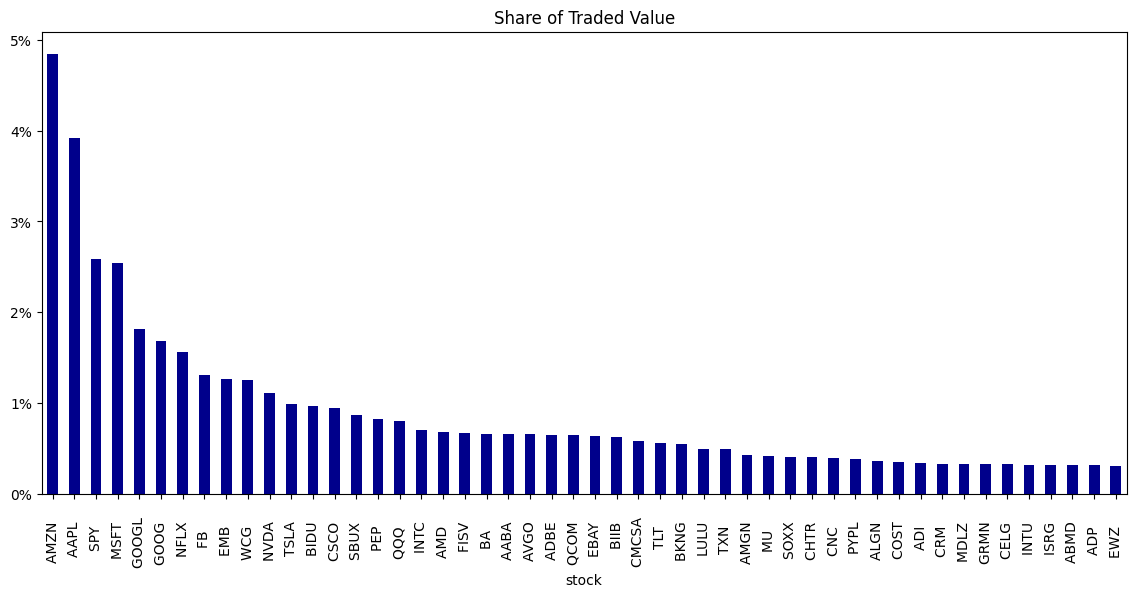

In [93]:
with pd.HDFStore(itch_store) as store:
    stocks = store['R'].loc[:, ['stock_locate', 'stock']]
    # trades = store['P'].append(store['Q'].rename(columns={'cross_price': 'price'}), sort=False).merge(stocks)
    trades = pd.concat([
    store['P'],
    store['Q'].rename(columns={'cross_price': 'price'})
        ], ignore_index=True).merge(stocks, on='stock_locate')

trades['value'] = trades.shares.mul(trades.price)
trades['value_share'] = trades.value.div(trades.value.sum())
trade_summary = trades.groupby('stock').value_share.sum().sort_values(ascending=False)
trade_summary.iloc[:50].plot.bar(figsize=(14, 6), color='darkblue', title='Share of Traded Value')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

## Build Order Book

In [94]:
stock = 'AAPL'
order_dict = {-1: 'sell', 1: 'buy'}

The parsed messages allow us to rebuild the order flow for the given day. The 'R' message type contains a listing of all stocks traded during a given day, including information about initial public offerings (IPOs) and trading restrictions.

Throughout the day, new orders are added, and orders that are executed and canceled are removed from the order book. The proper accounting for messages that reference orders placed on a prior date would require tracking the order book over multiple days, but we are ignoring this aspect here.

### Get all messages for given stock

The `get_messages()` function illustrates how to collect the orders for a single stock that affects trading (refer to the ITCH specification for details about each message):

In [95]:
with pd.HDFStore(itch_store) as store:
    df_r = store['R']
    print(df_r.columns)
    print(list(df_r['stock'].unique()))
    # print(df_r['stock'].unique())


Index(['stock_locate', 'tracking_number', 'timestamp', 'stock',
       'market_category', 'financial_status_indicator', 'round_lot_size',
       'round_lots_only', 'issue_classification', 'issue_sub_type',
       'authenticity', 'short_sale_threshold_indicator', 'ipo_flag',
       'luld_reference_price_tier', 'etp_flag', 'etp_leverage_factor',
       'inverse_indicator'],
      dtype='object')
['A       ', 'AA      ', 'AAAU    ', 'AABA    ', 'AAC     ', 'AADR    ', 'AAL     ', 'AAMC    ', 'AAME    ', 'AAN     ', 'AAOI    ', 'AAON    ', 'AAP     ', 'AAPL    ', 'AAT     ', 'AAU     ', 'AAWW    ', 'AAXJ    ', 'AAXN    ', 'AB      ', 'ABB     ', 'ABBV    ', 'ABC     ', 'ABCB    ', 'ABDC    ', 'ABEO    ', 'ABEOW   ', 'ABEV    ', 'ABG     ', 'ABIL    ', 'ABIO    ', 'ABM     ', 'ABMD    ', 'ABR     ', 'ABR-A   ', 'ABR-B   ', 'ABR-C   ', 'ABT     ', 'ABTX    ', 'ABUS    ', 'AC      ', 'ACA     ', 'ACAD    ', 'ACAMU   ', 'ACB     ', 'ACBI    ', 'ACC     ', 'ACCO    ', 'ACER    ', 'ACES    ', 'A

In [96]:
def get_messages(date, stock=stock):
    """Collect trading messages for given stock"""
    with pd.HDFStore(itch_store) as store:
        # df_r = store.select('R')
        # df_r['stock'] = df_r['stock'].str.strip()  # Remove trailing spaces
        # print(list(df_r['stock'].unique()))
        # stock_locate = df_r[df_r['stock'] == stock].stock_locate.iloc[0]
        df_r = store.select('R')
        df_r['stock'] = df_r['stock'].str.strip()
        stock_locate = int(df_r[df_r['stock'] == stock].stock_locate.iloc[0])  # cast to int
        target = f'stock_locate = {stock_locate}'  # safe for HDF query

        # stock_locate = store.select('R', where=f'stock == "{stock}"').stock_locate.iloc[0]
        target = 'stock_locate = stock_locate'

        data = {}
        # trading message types
        messages = ['A', 'F', 'E', 'C', 'X', 'D', 'U', 'P', 'Q']
        for m in messages:
            data[m] = store.select(m, where=target).drop('stock_locate', axis=1).assign(type=m)

    order_cols = ['order_reference_number', 'buy_sell_indicator', 'shares', 'price']
    orders = pd.concat([data['A'], data['F']], sort=False, ignore_index=True).loc[:, order_cols]

    for m in messages[2: -3]:
        data[m] = data[m].merge(orders, how='left')

    data['U'] = data['U'].merge(orders, how='left',
                                right_on='order_reference_number',
                                left_on='original_order_reference_number',
                                suffixes=['', '_replaced'])

    data['Q'].rename(columns={'cross_price': 'price'}, inplace=True)
    data['X']['shares'] = data['X']['cancelled_shares']
    data['X'] = data['X'].dropna(subset=['price'])

    data = pd.concat([data[m] for m in messages], ignore_index=True, sort=False)
    data['date'] = pd.to_datetime(date, format='%m%d%Y')
    data.timestamp = data['date'].add(data.timestamp)
    data = data[data.printable != 0]

    drop_cols = ['tracking_number', 'order_reference_number', 'original_order_reference_number',
                 'cross_type', 'new_order_reference_number', 'attribution', 'match_number',
                 'printable', 'date', 'cancelled_shares']
    return data.drop(drop_cols, axis=1).sort_values('timestamp').reset_index(drop=True)


In [97]:
messages = get_messages(date=date, stock=stock)


In [98]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2010107 entries, 0 to 2010106
Data columns (total 9 columns):
 #   Column              Dtype         
---  ------              -----         
 0   timestamp           datetime64[ns]
 1   buy_sell_indicator  object        
 2   shares              float64       
 3   price               float64       
 4   type                object        
 5   executed_shares     float64       
 6   execution_price     float64       
 7   shares_replaced     float64       
 8   price_replaced      float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 138.0+ MB


In [99]:
with pd.HDFStore(order_book_store) as store:
    key = '{}/messages'.format(stock)
    store.put(key, messages)
    print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: ../../data/order_book.h5
/AAPL/messages            frame        (shape->[2010107,9])
/AAPL/trades              frame        (shape->[72294,3])  


/var/folders/_1/hlx9skzx2wd47fbwgn286hkm0000gn/T/ipykernel_17882/3677458448.py:3: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['buy_sell_indicator', 'type'], dtype='object')]

  store.put(key, messages)


### Combine Trading Records

Reconstructing successful trades, that is, orders that are executed as opposed to those that were canceled from trade-related message types, C, E, P, and Q, is relatively straightforward:

In [100]:
def get_trades(m):
    """Combine C, E, P and Q messages into trading records"""
    trade_dict = {'executed_shares': 'shares', 'execution_price': 'price'}
    cols = ['timestamp', 'executed_shares']
    trades = pd.concat([m.loc[m.type == 'E', cols + ['price']].rename(columns=trade_dict),
                        m.loc[m.type == 'C', cols + ['execution_price']].rename(columns=trade_dict),
                        m.loc[m.type == 'P', ['timestamp', 'price', 'shares']],
                        m.loc[m.type == 'Q', ['timestamp', 'price', 'shares']].assign(cross=1),
                        ], sort=False).dropna(subset=['price']).fillna(0)
    return trades.set_index('timestamp').sort_index().astype(int)

In [101]:
trades = get_trades(messages)
print(trades.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59804 entries, 2019-03-27 04:00:56.459428646 to 2019-03-27 19:54:05.600648466
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   shares  59804 non-null  int64
 1   price   59804 non-null  int64
 2   cross   59804 non-null  int64
dtypes: int64(3)
memory usage: 1.8 MB
None


In [102]:
with pd.HDFStore(order_book_store) as store:
    store.put('{}/trades'.format(stock), trades)

### Create Orders

The order book keeps track of limit orders, and the various price levels for buy and sell orders constitute the depth of the order book. To reconstruct the order book for a given level of depth requires the following steps:


The `add_orders()` function accumulates sell orders in ascending, and buy orders in descending order for a given timestamp up to the desired level of depth:

In [103]:
def add_orders(orders, buysell, nlevels):
    """Add orders up to desired depth given by nlevels;
        sell in ascending, buy in descending order
    """
    new_order = []
    items = sorted(orders.copy().items())
    if buysell == 1:
        items = reversed(items)  
    for i, (p, s) in enumerate(items, 1):
        new_order.append((p, s))
        if i == nlevels:
            break
    return orders, new_order

In [104]:
print(len(messages))

2010107


In [105]:
# def save_orders(orders, append=False):
#     cols = ['price', 'shares']
#     for buysell, book in orders.items():
#         df = (pd.concat([pd.DataFrame(data=data,
#                                      columns=cols)
#                          .assign(timestamp=t) 
#                          for t, data in book.items()]))
#         key = '{}/{}'.format(stock, order_dict[buysell])
#         df.loc[:, ['price', 'shares']] = df.loc[:, ['price', 'shares']].astype(int)
#         with pd.HDFStore(order_book_store) as store:
#             if append:
#                 store.append(key, df.set_index('timestamp'), format='t')
#             else:
#                 store.put(key, df.set_index('timestamp'))

def save_orders(orders, append=False):
    cols = ['price', 'shares']
    
    for buysell, book in orders.items():
        if not book:  # ✅ Skip if no entries for this side of book
            continue

        dfs = []
        for t, data in book.items():
            if data:  # ✅ Ensure there’s data at this timestamp
                df = pd.DataFrame(data=data, columns=cols).assign(timestamp=t)
                dfs.append(df)

        if not dfs:  # ✅ Skip if all timestamps had no data
            continue

        df = pd.concat(dfs)
        key = f'{stock}/{order_dict[buysell]}'
        df[['price', 'shares']] = df[['price', 'shares']].astype(int)

        with pd.HDFStore(order_book_store) as store:
            if append:
                store.append(key, df.set_index('timestamp'), format='t')
            else:
                store.put(key, df.set_index('timestamp'))


We iterate over all ITCH messages and process orders and their replacements as required by the specification (this can take a while):

In [106]:
print(vars(messages))


{'_is_copy': None, '_mgr': BlockManager
Items: Index(['timestamp', 'buy_sell_indicator', 'shares', 'price', 'type',
       'executed_shares', 'execution_price', 'shares_replaced',
       'price_replaced'],
      dtype='object')
Axis 1: RangeIndex(start=0, stop=2010107, step=1)
DatetimeLikeBlock: slice(0, 1, 1), 1 x 2010107, dtype: datetime64[ns]
NumpyBlock: slice(1, 7, 3), 2 x 2010107, dtype: object
NumpyBlock: [2 3 5 6 7 8], 6 x 2010107, dtype: float64, '_item_cache': {'timestamp': 0         2019-03-27 04:00:00.006432545
1         2019-03-27 04:00:00.008777412
2         2019-03-27 04:00:00.016498868
3         2019-03-27 04:00:00.017857990
4         2019-03-27 04:00:03.597489791
                       ...             
2010102   2019-03-27 20:00:00.073334596
2010103   2019-03-27 20:00:00.073447563
2010104   2019-03-27 20:00:00.073477970
2010105   2019-03-27 20:00:00.074023439
2010106   2019-03-27 20:00:00.074213874
Name: timestamp, Length: 2010107, dtype: datetime64[ns], 'buy_sell_indic

In [114]:
order_book = {-1: {}, 1: {}}
current_orders = {-1: Counter(), 1: Counter()}
message_counter = Counter()
nlevels = 100

# Preprocess the entire column once
messages['buy_sell_indicator'] = messages['buy_sell_indicator'].str.strip().map(encoding.get('buy_sell_indicator')).astype(float)

start = time()
for message in messages.itertuples():
    i = message[0]
    # message.buy_sell_indicator = message.buy_sell_indicator.strip().map(encoding.get('buy_sell_indicator'))

    if i % 1e5 == 0 and i > 0:
        print('{:,.0f}\t\t{}'.format(i, timedelta(seconds=time() - start)))
        save_orders(order_book, append=True)
        order_book = {-1: {}, 1: {}}
        start = time()
        print(f'message type: {message.type}, buy/sell: {message.buy_sell_indicator}, price: {message.price}, shares: {message.shares}')
    if np.isnan(message.buy_sell_indicator):
        continue
    message_counter.update(message.type)

    buysell = message.buy_sell_indicator
    price, shares = None, None

    if message.type in ['A', 'F', 'U']:
        price = int(message.price)
        shares = int(message.shares)

        current_orders[buysell].update({price: shares})
        current_orders[buysell], new_order = add_orders(current_orders[buysell], buysell, nlevels)
        order_book[buysell][message.timestamp] = new_order

    if message.type in ['E', 'C', 'X', 'D', 'U']:
        if message.type == 'U':
            if not np.isnan(message.shares_replaced):
                price = int(message.price_replaced)
                shares = -int(message.shares_replaced)
        else:
            if not np.isnan(message.price):
                price = int(message.price)
                shares = -int(message.shares)

        if price is not None:
            current_orders[buysell].update({price: shares})
            if current_orders[buysell][price] <= 0:
                current_orders[buysell].pop(price)
            current_orders[buysell], new_order = add_orders(current_orders[buysell], buysell, nlevels)
            order_book[buysell][message.timestamp] = new_order

100,000		0:00:14.212427
message type: D, buy/sell: 1.0, price: 1890300.0, shares: 300.0
200,000		0:00:21.571458
message type: A, buy/sell: -1.0, price: 1889800.0, shares: 10.0
300,000		0:00:21.939219
message type: D, buy/sell: 1.0, price: 1885600.0, shares: 100.0
400,000		0:00:21.299769
message type: A, buy/sell: -1.0, price: 1889400.0, shares: 100.0
500,000		0:00:21.368068
message type: D, buy/sell: -1.0, price: 1892600.0, shares: 100.0
600,000		0:00:20.516282
message type: U, buy/sell: nan, price: 1888300.0, shares: 100.0
700,000		0:00:20.986745
message type: U, buy/sell: nan, price: 1830800.0, shares: 100.0
800,000		0:00:21.610656
message type: A, buy/sell: 1.0, price: 1879200.0, shares: 100.0
900,000		0:00:22.263776
message type: D, buy/sell: -1.0, price: 1869400.0, shares: 100.0
1,000,000		0:00:23.204430
message type: A, buy/sell: -1.0, price: 1874800.0, shares: 100.0
1,100,000		0:00:23.322091
message type: A, buy/sell: -1.0, price: 1884500.0, shares: 2.0
1,200,000		0:00:22.777728

In [115]:
message_counter = pd.Series(message_counter)
print(message_counter)

A    924117
D    869968
X      2789
E     52299
P      6995
F      2282
U     14159
C       481
dtype: int64


In [116]:
with pd.HDFStore(order_book_store) as store:
    print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: ../../data/order_book.h5
/AAPL/buy                 frame_table  (typ->appendable,nrows->88553421,ncols->2,indexers->[index],dc->[])
/AAPL/messages            frame        (shape->[2010107,9])                                               
/AAPL/sell                frame_table  (typ->appendable,nrows->91632907,ncols->2,indexers->[index],dc->[])
/AAPL/trades              frame        (shape->[59804,3])                                                 


In [ ]:
with pd.HDFStore(order_book_store) as store:
    print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: data/order_book.h5
/AAPL/buy                 frame_table  (typ->appendable,nrows->88554121,ncols->2,indexers->[index],dc->[])
/AAPL/messages            frame        (shape->[2010099,9])                                               
/AAPL/sell                frame_table  (typ->appendable,nrows->91632307,ncols->2,indexers->[index],dc->[])
/AAPL/trades              frame        (shape->[59796,3])                                                 


## Order Book Depth

In [117]:
with pd.HDFStore(order_book_store) as store:
    buy = store['{}/buy'.format(stock)].reset_index().drop_duplicates()
    sell = store['{}/sell'.format(stock)].reset_index().drop_duplicates()

### Price to Decimals

In [118]:
buy.price = buy.price.mul(1e-4)
sell.price = sell.price.mul(1e-4)

### Remove outliers

In [119]:
percentiles = [.01, .02, .1, .25, .75, .9, .98, .99]
pd.concat([buy.price.describe(percentiles=percentiles).to_frame('buy'),
           sell.price.describe(percentiles=percentiles).to_frame('sell')], axis=1)

,buy,sell
count,8.855342e+07,9.163291e+07
mean,1.889559e+02,1.927302e+02
std,2.192714e+00,9.468973e+02
min,1.000000e-04,1.865500e+02
1%,1.878300e+02,1.866300e+02
2%,1.880000e+02,1.867900e+02
10%,1.885200e+02,1.870800e+02
25%,1.887200e+02,1.873900e+02
50%,1.890300e+02,1.879600e+02
75%,1.893800e+02,1.888000e+02


In [120]:
buy = buy[buy.price > buy.price.quantile(.01)]
sell = sell[sell.price < sell.price.quantile(.99)]

### Buy-Sell Order Distribution

The number of orders at different price levels, highlighted in the following screenshot using different intensities for buy and sell orders, visualizes the depth of liquidity at any given point in time.

The distribution of limit order prices was weighted toward buy orders at higher prices.

In [121]:
market_open='0930'
market_close = '1600'

In [123]:
import seaborn as sns

/var/folders/_1/hlx9skzx2wd47fbwgn286hkm0000gn/T/ipykernel_17882/1503744707.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(buy.set_index('timestamp').between_time(market_open, market_close).price, ax=ax, label='Buy', kde=False, hist_kws=hist_kws)
/var/folders/_1/hlx9skzx2wd47fbwgn286hkm0000gn/T/ipykernel_17882/1503744707.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please s

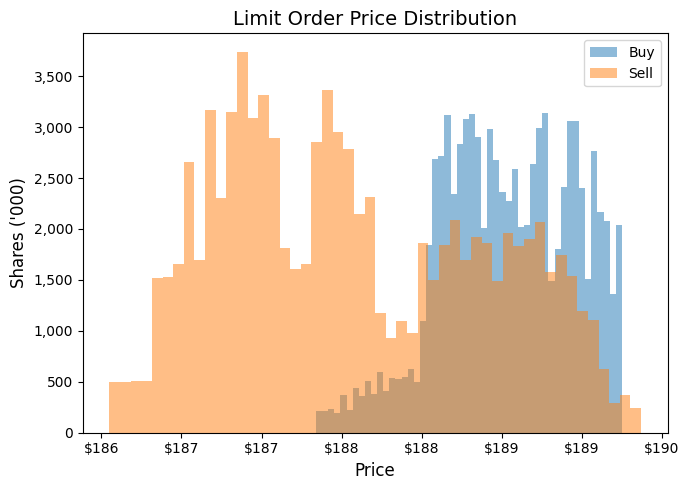

In [124]:
fig, ax = plt.subplots(figsize=(7,5))
hist_kws = {'linewidth': 1, 'alpha': .5}
sns.distplot(buy.set_index('timestamp').between_time(market_open, market_close).price, ax=ax, label='Buy', kde=False, hist_kws=hist_kws)
sns.distplot(sell.set_index('timestamp').between_time(market_open, market_close).price, ax=ax, label='Sell', kde=False, hist_kws=hist_kws)
plt.legend(fontsize=10)
plt.title('Limit Order Price Distribution', fontsize=14)
ax.set_yticklabels(['{:,}'.format(int(y/1000)) for y in ax.get_yticks().tolist()])
ax.set_xticklabels(['${:,}'.format(int(x)) for x in ax.get_xticks().tolist()])
plt.xlabel('Price', fontsize=12)
plt.ylabel('Shares (\'000)', fontsize=12)
plt.tight_layout()
# plt.savefig('figures/price_distribution', dpi=600);

### Order Book Depth

In [125]:
utc_offset = timedelta(hours=4)
depth = 100

In [126]:
buy_per_min = (buy
               .groupby([pd.Grouper(key='timestamp', freq='Min'), 'price'])
               .shares
               .sum()
               .apply(np.log)
               .to_frame('shares')
               .reset_index('price')
               .between_time(market_open, market_close)
               .groupby(level='timestamp', as_index=False, group_keys=False)
               .apply(lambda x: x.nlargest(columns='price', n=depth))
               .reset_index())
buy_per_min.timestamp = buy_per_min.timestamp.add(utc_offset).astype(int)
buy_per_min.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39093 entries, 0 to 39092
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  39093 non-null  int64  
 1   price      39093 non-null  float64
 2   shares     39093 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 916.4 KB


In [127]:
sell_per_min = (sell
                .groupby([pd.Grouper(key='timestamp', freq='Min'), 'price'])
                .shares
                .sum()
                .apply(np.log)
                .to_frame('shares')
                .reset_index('price')
                .between_time(market_open, market_close)
                .groupby(level='timestamp', as_index=False, group_keys=False)
                .apply(lambda x: x.nsmallest(columns='price', n=depth))
                .reset_index())

sell_per_min.timestamp = sell_per_min.timestamp.add(utc_offset).astype(int)
sell_per_min.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39085 entries, 0 to 39084
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  39085 non-null  int64  
 1   price      39085 non-null  float64
 2   shares     39085 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 916.2 KB


In [128]:
with pd.HDFStore(order_book_store) as store:
    trades = store['{}/trades'.format(stock)]
trades.price = trades.price.mul(1e-4)
trades = trades[trades.cross == 0].between_time(market_open, market_close)

trades_per_min = (trades
                  .resample('Min')
                  .agg({'price': 'mean', 'shares': 'sum'}))
trades_per_min.index = trades_per_min.index.to_series().add(utc_offset).astype(int)
trades_per_min.info()

<class 'pandas.core.frame.DataFrame'>
Index: 390 entries, 1553693400000000000 to 1553716740000000000
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   390 non-null    float64
 1   shares  390 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 9.1 KB


The following plots the evolution of limit orders and prices throughout the trading day: the dark line tracks the prices for executed trades during market hours, whereas the red and blue dots indicate individual limit orders on a per-minute basis (see notebook for details)

/var/folders/_1/hlx9skzx2wd47fbwgn286hkm0000gn/T/ipykernel_17882/447932589.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks)


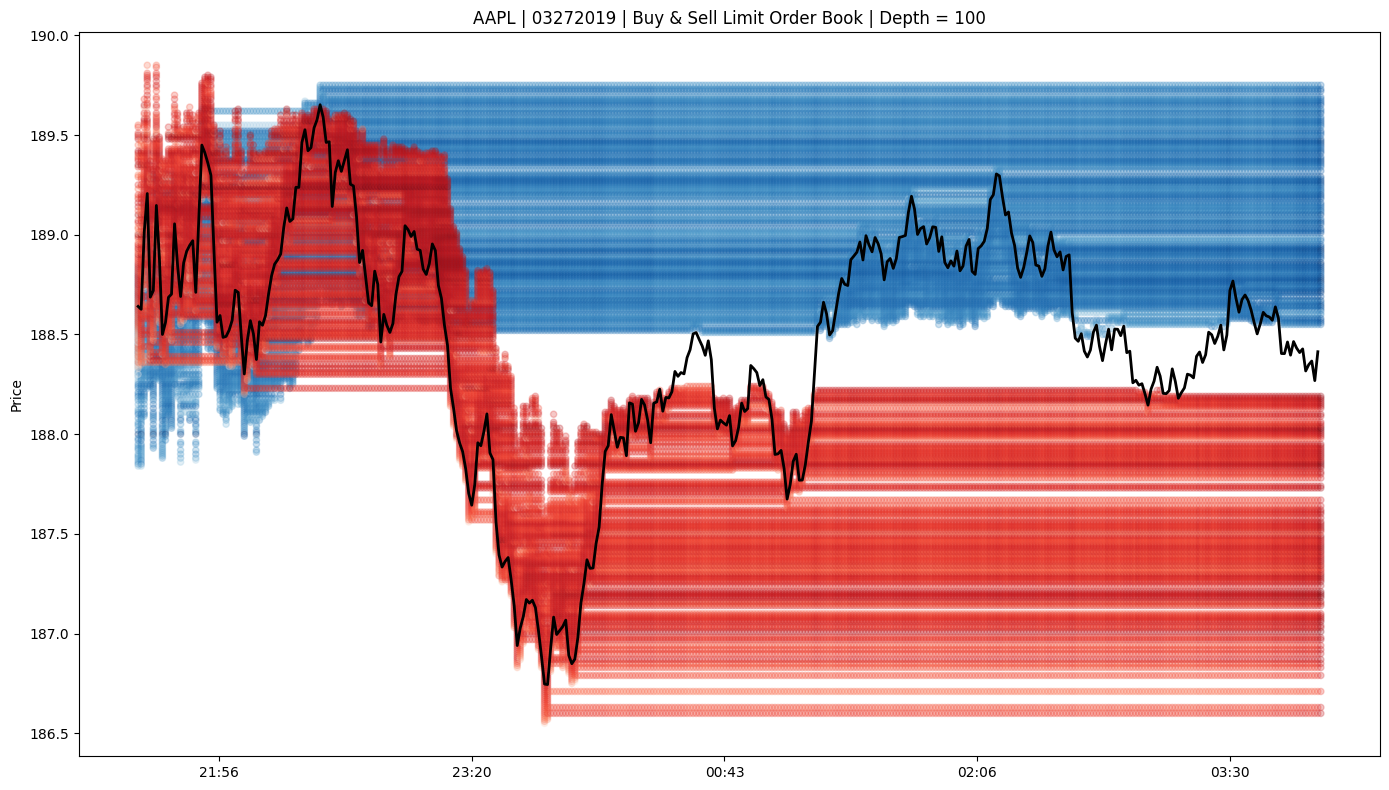

In [129]:
fig, ax = plt.subplots(figsize=(7, 5))

buy_per_min.plot.scatter(x='timestamp',y='price', c='shares', ax=ax, colormap='Blues', colorbar=False, alpha=.25)
sell_per_min.plot.scatter(x='timestamp',y='price', c='shares', ax=ax, colormap='Reds', colorbar=False, alpha=.25)
trades_per_min.price.plot(figsize=(14, 8), c='k', ax=ax, lw=2, 
                          title=f'AAPL | {date} | Buy & Sell Limit Order Book | Depth = {depth}')

xticks = [datetime.fromtimestamp(ts / 1e9).strftime('%H:%M') for ts in ax.get_xticks()]
ax.set_xticklabels(xticks)

ax.set_xlabel('')
ax.set_ylabel('Price')

fig.tight_layout()
# fig.savefig('figures/order_book', dpi=600);